<a href="https://colab.research.google.com/github/Aravindr017/SKINOVA/blob/model-evaluation-exporting/Model/Skinova_AI_skin_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES


#### 1. Environment Setup & Package Installation
Install required dependencies for data processing, image manipulation, and deep learning framework operations.

In [165]:
%pip install -q pandas numpy opencv-python pillow matplotlib seaborn scikit-learn tqdm



Note: you may need to restart the kernel to use updated packages.


#### 2. Import Libraries & Configure Environment
Import necessary Python packages for data manipulation, computer vision, data visualization, and model development.

In [166]:
import os

print(os.listdir("/kaggle/input"))


['datasets']


In [167]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

In [168]:
for dirname, dirs, files in os.walk("/kaggle/input"):
    print("\nFolder:", dirname)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])



Folder: /kaggle/input
Subfolders: ['datasets']
Files: []

Folder: /kaggle/input/datasets
Subfolders: ['surajghuwalewala']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala
Subfolders: ['ham1000-segmentation-and-classification']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'I

In [169]:
from pathlib import Path
import os
import pandas as pd

# ------------------------------------------------------------
# DATASET PATH
# ------------------------------------------------------------
# Find GroundTruth.csv automatically so the notebook works
# even if Kaggle changes the mounted dataset directory name.
candidates = list(Path("/kaggle/input").rglob("GroundTruth.csv"))

if not candidates:
    raise FileNotFoundError(
        "GroundTruth.csv was not found under /kaggle/input. "
        "Please attach the HAM10000 Segmentation and Classification dataset."
    )

metadata_path = candidates[0]
DATA_ROOT = metadata_path.parent

print("Dataset root:", DATA_ROOT)
print("GroundTruth.csv:", metadata_path)
print("Dataset exists:", DATA_ROOT.exists())


Dataset root: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
GroundTruth.csv: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/GroundTruth.csv
Dataset exists: True


## Exploratory Data Analysis (EDA)
Load the ground truth labels and inspect the class distribution, missing values, and dataset size.

In [170]:
# Load dataset metadata
df = pd.read_csv(metadata_path)

if "image" not in df.columns:
    raise ValueError(
        "GroundTruth.csv must contain an 'image' column."
    )

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (10015, 8)

Columns:
['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [171]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB
None


In [172]:
print(df.head(10))


          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
5  ISIC_0024311  0.0  1.0  0.0    0.0  0.0  0.0   0.0
6  ISIC_0024312  0.0  0.0  0.0    0.0  1.0  0.0   0.0
7  ISIC_0024313  1.0  0.0  0.0    0.0  0.0  0.0   0.0
8  ISIC_0024314  0.0  1.0  0.0    0.0  0.0  0.0   0.0
9  ISIC_0024315  1.0  0.0  0.0    0.0  0.0  0.0   0.0


In [173]:
for root, dirs, files in os.walk(DATA_ROOT):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])


Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'ISIC_0026281_segmentation.png', 'ISIC_0024577_segmentation.png', 'ISIC_0024910_segmentation.png', 'ISIC_0031771_segmentation.png', 'ISIC_0029679_segmentation.png']


In [174]:
# Expected HAM10000 one-hot label columns
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

missing_classes = [c for c in classes if c not in df.columns]
if missing_classes:
    raise ValueError(
        f"Missing label columns in GroundTruth.csv: {missing_classes}"
    )

label_columns = classes.copy()
print("Label columns:", label_columns)


Label columns: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [175]:
# Check each class
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

for col in classes:
    print(f"{col}: {df[col].sum()}")


MEL: 1113.0
NV: 6705.0
BCC: 514.0
AKIEC: 327.0
BKL: 1099.0
DF: 115.0
VASC: 142.0


In [176]:
# ============================================================
# LABEL PREPROCESSING
# ============================================================

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

# Convert one-hot label columns to numeric
df[classes] = df[classes].apply(pd.to_numeric, errors="coerce")
df[classes] = df[classes].fillna(0)

# A valid row must have exactly one positive class
df["label_sum"] = df[classes].sum(axis=1)

invalid_label_rows = (df["label_sum"] != 1).sum()
print("Rows with invalid label encoding:", invalid_label_rows)

df = df[df["label_sum"] == 1].copy()
df["label"] = df[classes].idxmax(axis=1)

# Fixed class order is important for reproducible model outputs.
class_to_id = {name: idx for idx, name in enumerate(classes)}
id_to_label = {idx: name for name, idx in class_to_id.items()}
df["label_id"] = df["label"].map(class_to_id).astype(int)

print("\nClass mapping:")
for class_id, class_name in id_to_label.items():
    print(f"{class_id} -> {class_name}")

print("\nClass distribution:")
print(df["label"].value_counts().reindex(classes, fill_value=0))

display(df[["image", "label", "label_id"]].head(10))


Rows with invalid label encoding: 0

Class mapping:
0 -> MEL
1 -> NV
2 -> BCC
3 -> AKIEC
4 -> BKL
5 -> DF
6 -> VASC

Class distribution:
label
MEL      1113
NV       6705
BCC       514
AKIEC     327
BKL      1099
DF        115
VASC      142
Name: count, dtype: int64


,image,label,label_id
0,ISIC_0024306,NV,1
1,ISIC_0024307,NV,1
2,ISIC_0024308,NV,1
3,ISIC_0024309,NV,1
4,ISIC_0024310,MEL,0
5,ISIC_0024311,NV,1
6,ISIC_0024312,BKL,4
7,ISIC_0024313,MEL,0
8,ISIC_0024314,NV,1
9,ISIC_0024315,MEL,0


In [177]:
# Check image files
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_files = [
    path for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("Total image files found:", len(image_files))
print("\nFirst 10 images:")
for path in image_files[:10]:
    print(path)


Total image files found: 20030

First 10 images:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028100.jpg
/kaggle/input/d

In [178]:
# Check for segmentation/mask files
mask_files = [
    path for path in DATA_ROOT.rglob("*")
    if path.is_file()
    and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    and any(token in path.stem.lower() for token in ["mask", "segmentation", "segment"])
]

print("Possible mask files:", len(mask_files))
for path in mask_files[:20]:
    print(path)


Possible mask files: 10015
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0033034_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0026058_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0031698_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0032330_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0030246_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0026281_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0024577_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0024910_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham10

In [179]:
#Check the image names against the CSV
print("CSV image examples:")
print(df["image"].head(10).tolist())


CSV image examples:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']


In [180]:
print("\nActual image examples:")

for path in image_files[:10]:
    print(path.name)



Actual image examples:
ISIC_0030912.jpg
ISIC_0028933.jpg
ISIC_0030585.jpg
ISIC_0028394.jpg
ISIC_0033697.jpg
ISIC_0030062.jpg
ISIC_0031213.jpg
ISIC_0027799.jpg
ISIC_0028100.jpg
ISIC_0027960.jpg


In [181]:
# Match CSV image IDs to actual image files.
# Use the first occurrence for duplicate stems.
image_path_dict = {}
for path in image_files:
    image_path_dict.setdefault(path.stem, str(path))

df["image_path"] = df["image"].astype(str).map(image_path_dict)

print(df[["image", "image_path"]].head(10))


          image                                         image_path
0  ISIC_0024306  /kaggle/input/datasets/surajghuwalewala/ham100...
1  ISIC_0024307  /kaggle/input/datasets/surajghuwalewala/ham100...
2  ISIC_0024308  /kaggle/input/datasets/surajghuwalewala/ham100...
3  ISIC_0024309  /kaggle/input/datasets/surajghuwalewala/ham100...
4  ISIC_0024310  /kaggle/input/datasets/surajghuwalewala/ham100...
5  ISIC_0024311  /kaggle/input/datasets/surajghuwalewala/ham100...
6  ISIC_0024312  /kaggle/input/datasets/surajghuwalewala/ham100...
7  ISIC_0024313  /kaggle/input/datasets/surajghuwalewala/ham100...
8  ISIC_0024314  /kaggle/input/datasets/surajghuwalewala/ham100...
9  ISIC_0024315  /kaggle/input/datasets/surajghuwalewala/ham100...


In [182]:
print(
    "Images found:",
    df["image_path"].notna().sum()
)

print(
    "Images missing:",
    df["image_path"].isna().sum()
)


Images found: 10015
Images missing: 0


In [183]:
# Remove records whose image file cannot be found
df = df.dropna(subset=["image_path"]).copy()

print("Remaining valid image records:", len(df))


Remaining valid image records: 10015


In [184]:
# Check for corrupted images
from PIL import Image
from tqdm import tqdm

bad_images = []

for path in tqdm(df["image_path"], desc="Checking images"):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_images.append(path)

print("Corrupted images:", len(bad_images))

if bad_images:
    bad_set = set(bad_images)
    df = df[~df["image_path"].isin(bad_set)].copy()
    print("Remaining records after removing corrupted images:", len(df))


Checking images: 100%|██████████| 10015/10015 [00:21<00:00, 468.82it/s]

Corrupted images: 0


In [185]:
#Check image dimensions
from collections import Counter

sizes = []

for path in tqdm(
    df["image_path"],
    desc="Checking dimensions"
):

    with Image.open(path) as img:
        sizes.append(img.size)

print("Most common image sizes:")

for size, count in Counter(sizes).most_common(10):
    print(size, ":", count)


Checking dimensions: 100%|██████████| 10015/10015 [00:14<00:00, 673.93it/s]

Most common image sizes:
(600, 450) : 10015


# Image Visualization
Display sample images from the dataset along with their corresponding ground truth annotations.

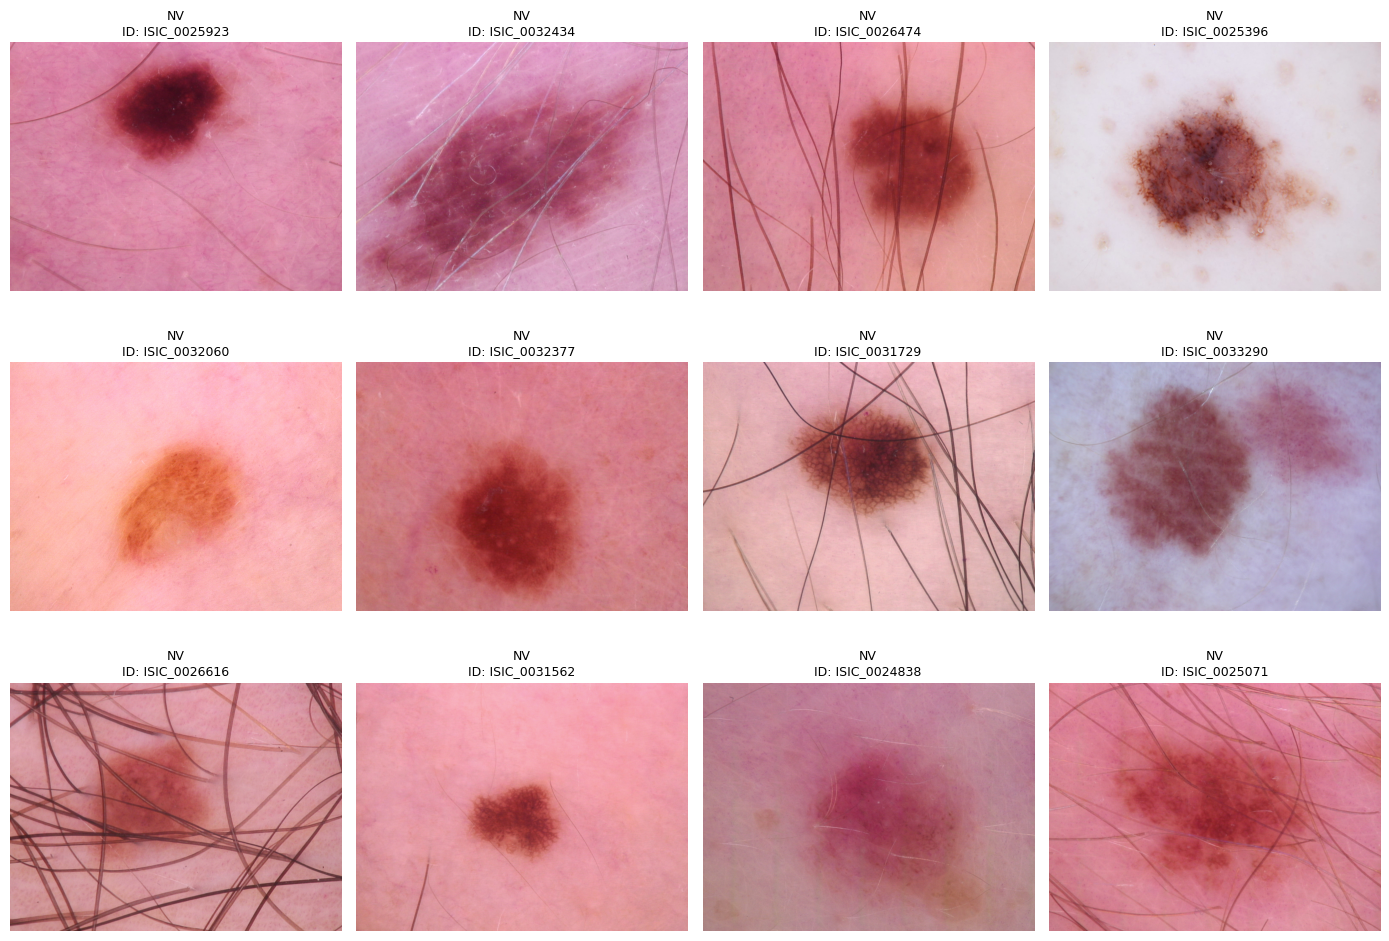

In [186]:
# Visualize sample images
import matplotlib.pyplot as plt
from PIL import Image

sample_n = min(12, len(df))
sample_df = df.sample(sample_n, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(f"{row['label']}\nID: {row['image']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


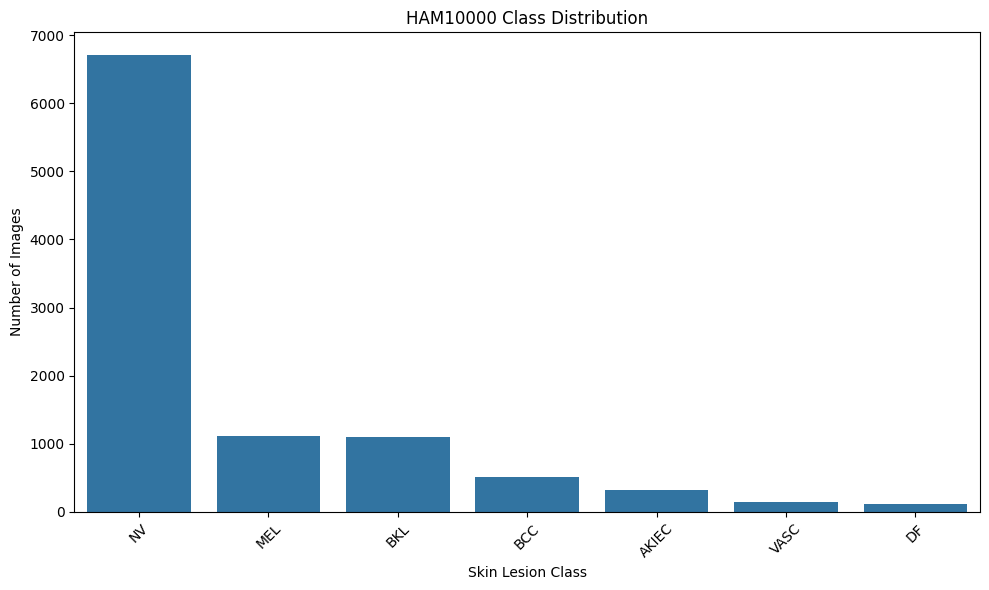

In [187]:
#Check class distribution visually
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title(
    "HAM10000 Class Distribution"
)

plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [188]:
#display percentages
class_distribution = df["label"].value_counts()

class_percentage = (
    df["label"].value_counts(normalize=True) * 100
).round(2)

distribution_table = pd.DataFrame({
    "Count": class_distribution,
    "Percentage": class_percentage
})

display(distribution_table)

,Count,Percentage
label,,
NV,6705,66.95
MEL,1113,11.11
BKL,1099,10.97
BCC,514,5.13
AKIEC,327,3.27
VASC,142,1.42
DF,115,1.15


In [189]:
#Save our cleaned metadata
from pathlib import Path

PROCESSED_DIR = Path("/kaggle/working/skinova_processed")

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [190]:
df.to_csv(
    PROCESSED_DIR / "cleaned_metadata.csv",
    index=False
)

print(
    "Saved to:",
    PROCESSED_DIR / "cleaned_metadata.csv"
)


Saved to: /kaggle/working/skinova_processed/cleaned_metadata.csv


In [191]:
print("Number of CSV rows:", len(df))

print("\nCSV image names:")
print(df["image"].head(10).tolist())

print("\nNumber of image files found:", len(image_files))

print("\nActual image files:")
for path in image_files[:20]:
    print(path)

print("\nNumber of mask files found:", len(mask_files))

print("\nActual mask files:")
for path in mask_files[:20]:
    print(path)


Number of CSV rows: 10015

CSV image names:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']

Number of image files found: 20030

Actual image files:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/in

In [192]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

SEED = 42

# 80% train, 10% validation, 10% test.
# Stratification preserves class proportions in all splits.
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples  :", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples   :", len(test_df))


Training samples  : 8012
Validation samples: 1001
Testing samples   : 1002


In [193]:
print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())


Training distribution:
label
NV       5364
MEL       890
BKL       879
BCC       411
AKIEC     262
VASC      114
DF         92
Name: count, dtype: int64

Validation distribution:
label
NV       670
MEL      111
BKL      110
BCC       51
AKIEC     33
VASC      14
DF        12
Name: count, dtype: int64

Test distribution:
label
NV       671
MEL      112
BKL      110
BCC       52
AKIEC     32
VASC      14
DF        11
Name: count, dtype: int64


# Data Augmentation

In [194]:
# Albumentations is used only for offline training-set balancing.
# If the package is already available, no installation is required.
try:
    import albumentations as A
except ImportError:
    %pip install -q albumentations
    import albumentations as A


In [195]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm


In [196]:
# ============================================================
# AUGMENTATION PIPELINE
# ============================================================

augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=0,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.15
    )
])

print("Augmentation pipeline created.")


Augmentation pipeline created.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [197]:
# ============================================================
# CREATE AUGMENTED DATASET DIRECTORY
# ============================================================

AUGMENTED_DIR = Path("/kaggle/working/skinova_augmented")

TRAIN_AUG_DIR = AUGMENTED_DIR / "train"

TRAIN_AUG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Augmented dataset directory:")
print(TRAIN_AUG_DIR)

Augmented dataset directory:
/kaggle/working/skinova_augmented/train


In [198]:
# ============================================================
# TRAINING CLASS DISTRIBUTION BEFORE AUGMENTATION
# ============================================================

train_distribution = train_df["label"].value_counts().sort_index()

print("Training distribution BEFORE augmentation:")
print(train_distribution)

Training distribution BEFORE augmentation:
label
AKIEC     262
BCC       411
BKL       879
DF         92
MEL       890
NV       5364
VASC      114
Name: count, dtype: int64


In [199]:
# ============================================================
# AUGMENTATION TARGET
# ============================================================

TARGET_IMAGES_PER_CLASS = 2000

print(
    "Target images per minority class:",
    TARGET_IMAGES_PER_CLASS
)

Target images per minority class: 2000


In [200]:
# ============================================================
# GENERATE AUGMENTED TRAINING IMAGES
# ============================================================

augmented_records = []

# Keep all original training images
for _, row in train_df.iterrows():
    augmented_records.append({
        "image": row["image"],
        "image_path": row["image_path"],
        "label": row["label"],
        "label_id": int(row["label_id"]),
        "is_augmented": 0
    })

rng = np.random.default_rng(SEED)

# Balance each class up to the target size.
for class_name in classes:
    class_df = train_df[train_df["label"] == class_name].copy()
    current_count = len(class_df)

    images_to_generate = max(
        0,
        TARGET_IMAGES_PER_CLASS - current_count
    )

    print(
        f"{class_name}: {current_count} original -> "
        f"{current_count + images_to_generate} target"
    )

    for i in tqdm(
        range(images_to_generate),
        desc=f"Augmenting {class_name}"
    ):
        row = class_df.iloc[
            int(rng.integers(0, len(class_df)))
        ]

        image = cv2.imread(str(row["image_path"]))
        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        augmented_image = augmentation_pipeline(image=image)["image"]
        augmented_image = cv2.cvtColor(
            augmented_image,
            cv2.COLOR_RGB2BGR
        )

        original_name = Path(row["image_path"]).stem
        new_filename = f"{original_name}_aug_{i:05d}.jpg"
        output_path = TRAIN_AUG_DIR / new_filename

        ok = cv2.imwrite(
            str(output_path),
            augmented_image,
            [cv2.IMWRITE_JPEG_QUALITY, 95]
        )

        if not ok:
            continue

        augmented_records.append({
            "image": new_filename,
            "image_path": str(output_path),
            "label": row["label"],
            "label_id": int(row["label_id"]),
            "is_augmented": 1
        })

print("\nData augmentation completed.")


MEL: 890 original -> 2000 target


Augmenting MEL: 100%|██████████| 1110/1110 [00:18<00:00, 60.20it/s]


NV: 5364 original -> 5364 target


Augmenting NV: 0it [00:00, ?it/s]


BCC: 411 original -> 2000 target


...

DF: 92 original -> 2000 target


Augmenting DF: 100%|██████████| 1908/1908 [00:29<00:00, 64.71it/s]


VASC: 114 original -> 2000 target


Augmenting VASC: 100%|██████████| 1886/1886 [00:25<00:00, 72.79it/s]


Data augmentation completed.


In [201]:
# ============================================================
# CREATE AUGMENTED TRAINING METADATA
# ============================================================

augmented_train_df = pd.DataFrame(
    augmented_records
)

print(
    "Total training images after augmentation:",
    len(augmented_train_df)
)

print("\nClass distribution AFTER augmentation:")
print(
    augmented_train_df["label"].value_counts()
)

Total training images after augmentation: 17364

Class distribution AFTER augmentation:
label
NV       5364
MEL      2000
BKL      2000
BCC      2000
DF       2000
AKIEC    2000
VASC     2000
Name: count, dtype: int64


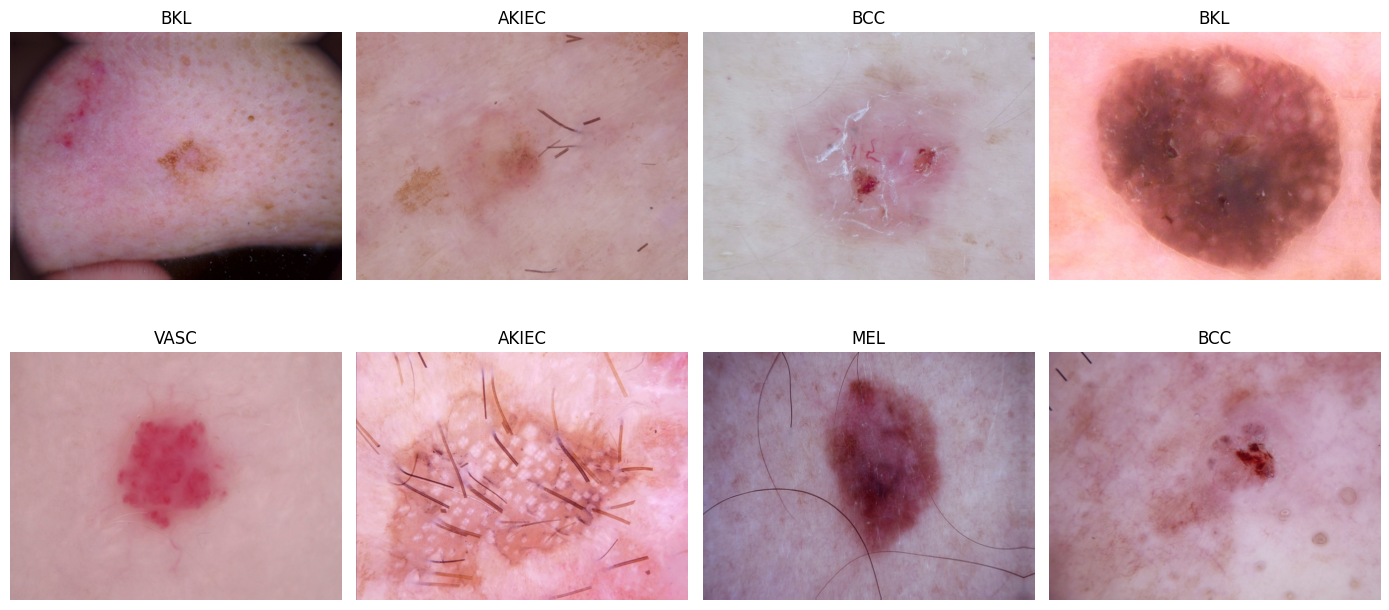

In [202]:
# ============================================================
# VISUALIZE AUGMENTED IMAGES
# ============================================================

import matplotlib.pyplot as plt

augmented_only = augmented_train_df[
    augmented_train_df["is_augmented"] == 1
]

if len(augmented_only) == 0:
    print("No augmented images were generated.")
else:
    sample_n = min(8, len(augmented_only))
    sample_aug = augmented_only.sample(
        sample_n,
        random_state=SEED
    )

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample_aug.iterrows()):
        image = cv2.imread(row["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.set_title(row["label"])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


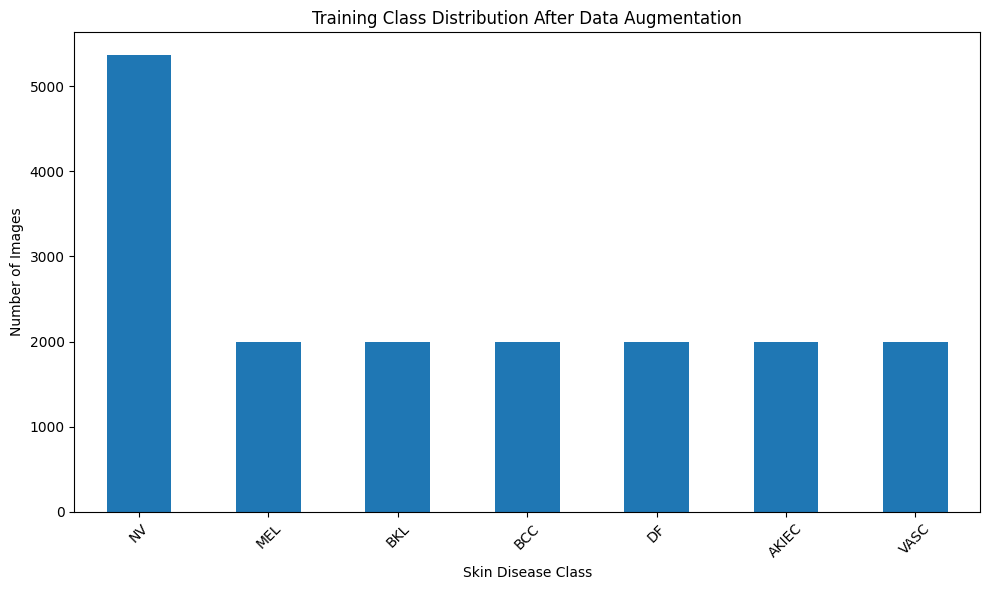

In [203]:
# ============================================================
# CLASS DISTRIBUTION AFTER AUGMENTATION
# ============================================================

plt.figure(figsize=(10, 6))

augmented_train_df["label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Training Class Distribution After Data Augmentation"
)

plt.xlabel("Skin Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [204]:
# ============================================================
# SAVE AUGMENTED METADATA
# ============================================================

augmented_metadata_path = (
    AUGMENTED_DIR /
    "augmented_train_metadata.csv"
)

augmented_train_df.to_csv(
    augmented_metadata_path,
    index=False
)

print(
    "Augmented metadata saved to:"
)

print(
    augmented_metadata_path
)

Augmented metadata saved to:
/kaggle/working/skinova_augmented/augmented_train_metadata.csv


In [205]:
# ============================================================
# SAVE VALIDATION AND TEST METADATA
# ============================================================

val_df.to_csv(
    AUGMENTED_DIR / "validation_metadata.csv",
    index=False
)

test_df.to_csv(
    AUGMENTED_DIR / "test_metadata.csv",
    index=False
)

print("Validation metadata saved.")
print("Test metadata saved.")

Validation metadata saved.
Test metadata saved.


# CNN Model Development

## Libraries

In [206]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Numerical and dataframe libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


from tensorflow.keras.preprocessing.image import ImageDataGenerator


TensorFlow version: 2.20.0


## Model Configuration

In [207]:
# Number of skin disease classes
NUM_CLASSES = 7

# Image size used for model training
IMG_SIZE = 240

# Number of images processed at one time
BATCH_SIZE = 32

# Random seed for reproducibility
SEED = 42

# Skin disease class names
CLASSES = [
    "AKIEC",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "VASC"
]

print("Number of classes:", NUM_CLASSES)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASSES)

Number of classes: 7
Image size: 240
Batch size: 32
Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


## Create Training, Validation and Test Generators

In [208]:
# No additional augmentation is applied by the generator because
# the training images were already balanced using offline augmentation.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=augmented_train_df,
    x_col="image_path",
    y_col="label",
    classes=CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    classes=CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    classes=CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)


Found 17364 validated image filenames belonging to 7 classes.
Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.

Class indices:
{'AKIEC': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'VASC': 6}


In [209]:
# CHECK TRAINING DATA

train_generator.reset()
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())


Image batch shape: (32, 240, 240, 3)
Label batch shape: (32, 7)
Minimum pixel value: 0.0
Maximum pixel value: 255.0


## Visualize Training Images

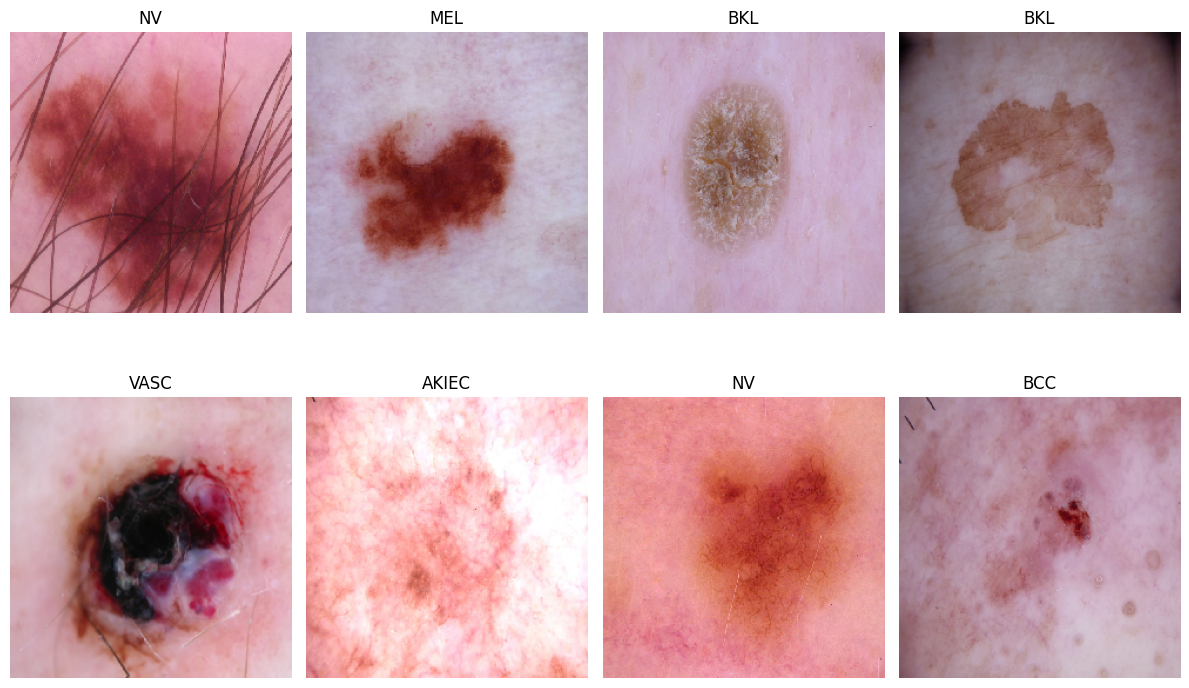

In [210]:
# VISUALIZE TRAINING BATCH

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].astype("uint8"))

    # Convert one-hot encoded label into class ID
    class_id = np.argmax(labels[i])

    # Get class name
    class_name = CLASSES[class_id]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Create Training Callbacks

In [211]:
# TRAINING CALLBACKS

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# Stop training if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

## MODEL 1  EfficientNetB0

In [212]:
# ============================================================
# BUILDING EFFICIENTNETB0
# ============================================================

from tensorflow.keras.applications import EfficientNetB0


def load_efficientnet_backbone(constructor, input_shape):
    """
    Load an ImageNet-pretrained EfficientNet backbone.

    IMPORTANT:
    We intentionally do NOT fall back to weights=None.
    If ImageNet weights cannot be loaded, training must stop.
    Silently using random weights can create a collapsed model
    that predicts nearly the same class distribution for every image.
    """
    print("Loading ImageNet pretrained weights...")

    backbone = constructor(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    print("SUCCESS: ImageNet pretrained weights loaded.")
    return backbone


base_b0 = load_efficientnet_backbone(
    EfficientNetB0,
    (IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained backbone for initial training
base_b0.trainable = False

efficientnet_b0 = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_b0,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

efficientnet_b0.summary()

print("EfficientNetB0 created successfully.")


Loading ImageNet pretrained weights...
SUCCESS: ImageNet pretrained weights loaded.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

EfficientNetB0 created successfully.


## Compile EfficientNetB0

In [213]:
efficientnet_b0.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully.")

EfficientNetB0 compiled successfully.


In [216]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class indices from the training generator
class_indices = train_generator.classes

# Get the unique class labels
classes = np.unique(class_indices)

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=class_indices
)

# Convert to dictionary for Keras
class_weight = dict(zip(classes, weights))

print("Class weights:")
for class_id, weight in class_weight.items():
    print(
        f"{class_id}: "
        f"{train_generator.class_indices and list(train_generator.class_indices.keys())[list(train_generator.class_indices.values()).index(class_id)]} "
        f"-> {weight:.4f}"
    )

Class weights:
0: AKIEC -> 1.2403
1: BCC -> 1.2403
2: BKL -> 1.2403
3: DF -> 1.2403
4: MEL -> 1.2403
5: NV -> 0.4624
6: VASC -> 1.2403


## Train EfficientNetB0

In [217]:
# ============================================================
# TRAIN EFFICIENTNET-B0
# ============================================================

checkpoint_b0 = ModelCheckpoint(
    "/kaggle/working/skinova_efficientnetb0_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_b0 = efficientnet_b0.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weight,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b0
    ]
)
print("Initial EfficientNetB0 training completed.")


Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.3767 - loss: 1.8287
Epoch 1: val_accuracy improved from None to 0.65335, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 1: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 153s 246ms/step - accuracy: 0.4756 - loss: 1.4887 - val_accuracy: 0.6533 - val_loss: 0.9923 - learning_rate: 1.0000e-04
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6172 - loss: 1.0300
Epoch 2: val_accuracy improved from 0.65335 to 0.69131, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 99s 182ms/step - accuracy: 0.6306 - loss: 0.9843 - val_accuracy: 0.6913 - val_loss: 0.8460 - learning_rate: 1.0000e-04
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6792 - loss: 0.8437
Epoch 3: val_accuracy improv

## Plot EfficientNetB0 Training Results

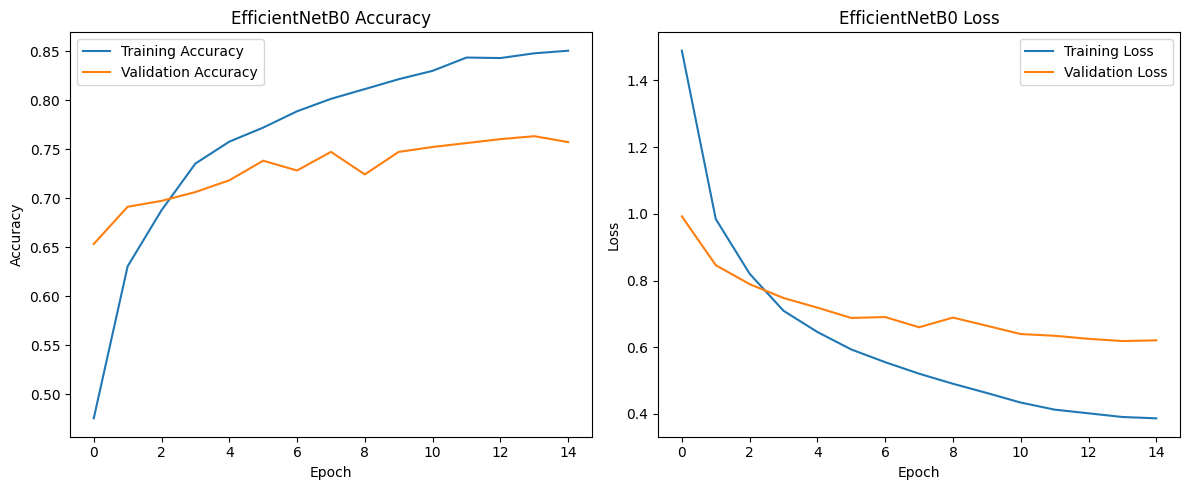

In [218]:
plt.figure(figsize=(12, 5))

# Training and validation accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_b0.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_b0.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Training and validation loss
plt.subplot(1, 2, 2)

plt.plot(
    history_b0.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_b0.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Fine-Tune EfficientNetB0

In [219]:
# ============================================================
# FINE-TUNE EFFICIENTNET-B0
# ============================================================

print("=" * 70)
print("STARTING EFFICIENTNET-B0 FINE-TUNING")
print("=" * 70)

# Unfreeze the backbone
base_b0.trainable = True

# Only the last 30 layers will be trainable
for layer in base_b0.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_b0.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile with a small learning rate
# to avoid destroying the pretrained features.
efficientnet_b0.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 ready for fine-tuning.")


STARTING EFFICIENTNET-B0 FINE-TUNING
EfficientNetB0 ready for fine-tuning.


In [220]:
# ============================================================
# FINE-TUNE EFFICIENTNET-B0
# ============================================================

history_b0_finetune = efficientnet_b0.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b0
    ]
)

# Reload the best checkpoint after fine-tuning.
efficientnet_b0_best = keras.models.load_model(
    "/kaggle/working/skinova_efficientnetb0_best.keras"
)

print("Best EfficientNetB0 checkpoint reloaded.")


Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8558 - loss: 0.3742
Epoch 1: val_accuracy did not improve from 0.76324
543/543 ━━━━━━━━━━━━━━━━━━━━ 147s 228ms/step - accuracy: 0.8561 - loss: 0.3717 - val_accuracy: 0.7632 - val_loss: 0.6014 - learning_rate: 1.0000e-05
Epoch 2/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8576 - loss: 0.3647
Epoch 2: val_accuracy improved from 0.76324 to 0.76424, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 97s 179ms/step - accuracy: 0.8611 - loss: 0.3549 - val_accuracy: 0.7642 - val_loss: 0.6029 - learning_rate: 1.0000e-05
Epoch 3/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8658 - loss: 0.3347
Epoch 3: val_accuracy improved from 0.76424 to 0.77323, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 3: finished saving model to /kaggle/working/skinova_

In [221]:
# ============================================================
# EFFICIENTNET-B0 MODEL HEALTH CHECK
# ============================================================
# This check is NOT intended to determine whether synthetic
# black/white/noise images are diseased.
# It only checks whether the trained network responds
# differently to very different inputs.

rng = np.random.default_rng(42)

health_inputs = {
    "BLACK": np.zeros(
        (1, IMG_SIZE, IMG_SIZE, 3),
        dtype=np.float32
    ),
    "WHITE": np.full(
        (1, IMG_SIZE, IMG_SIZE, 3),
        255.0,
        dtype=np.float32
    ),
    "NOISE_A": rng.uniform(
        0, 255,
        (1, IMG_SIZE, IMG_SIZE, 3)
    ).astype(np.float32),
    "NOISE_B": rng.uniform(
        0, 255,
        (1, IMG_SIZE, IMG_SIZE, 3)
    ).astype(np.float32),
}

health_outputs = {}

print("=" * 70)
print("EFFICIENTNET-B0 MODEL HEALTH CHECK")
print("=" * 70)

for name, image in health_inputs.items():
    prediction = efficientnet_b0_best.predict(
        image,
        verbose=0
    )[0]

    health_outputs[name] = prediction

    print("\n" + "-" * 60)
    print(name)

    for class_name, probability in zip(CLASSES, prediction):
        print(
            f"{class_name:6s}: "
            f"{probability * 100:7.3f}%"
        )

    print("TOP:", CLASSES[int(np.argmax(prediction))])

stacked_outputs = np.stack(
    list(health_outputs.values())
)

max_difference = float(
    np.abs(
        stacked_outputs[:, None, :] -
        stacked_outputs[None, :, :]
    ).max()
)

print("\n" + "=" * 70)
print(
    "Maximum output difference:",
    max_difference
)

if max_difference < 0.02:
    print("\n❌ MODEL HEALTH CHECK FAILED")
    print(
        "The model is producing almost identical outputs "
        "for very different inputs. DO NOT EXPORT THIS MODEL."
    )
else:
    print("\n✅ MODEL HEALTH CHECK PASSED")
    print(
        "The model responds differently to different inputs."
    )

print("=" * 70)


EFFICIENTNET-B0 MODEL HEALTH CHECK

------------------------------------------------------------
BLACK
AKIEC :   0.236%
BCC   :   0.916%
BKL   :   0.460%
DF    :  98.028%
MEL   :   0.186%
NV    :   0.057%
VASC  :   0.116%
TOP: DF

------------------------------------------------------------
WHITE
AKIEC :   1.266%
BCC   :  18.859%
BKL   :   1.559%
DF    :  74.480%
MEL   :   1.250%
NV    :   0.239%
VASC  :   2.347%
TOP: DF

------------------------------------------------------------
NOISE_A
AKIEC :   0.515%
BCC   :   3.576%
BKL   :   8.915%
DF    :   0.024%
MEL   :   4.552%
NV    :  81.424%
VASC  :   0.994%
TOP: NV

------------------------------------------------------------
NOISE_B
AKIEC :   0.037%
BCC   :   1.234%
BKL   :   0.838%
DF    :   0.000%
MEL   :   0.878%
NV    :  96.976%
VASC  :   0.038%
TOP: NV

Maximum output difference: 0.9802759885787964

✅ MODEL HEALTH CHECK PASSED
The model responds differently to different inputs.


In [222]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

test_generator.reset()
predictions = efficientnet_b0_best.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = CLASSES

print("EfficientNetB0 Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        digits=4,
        zero_division=0
)
)


32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 526ms/step
EfficientNetB0 Classification Report:

              precision    recall  f1-score   support

       AKIEC     0.4583    0.6875    0.5500        32
         BCC     0.6825    0.8269    0.7478        52
         BKL     0.5932    0.6364    0.6140       110
          DF     0.6429    0.8182    0.7200        11
         MEL     0.4928    0.6071    0.5440       112
          NV     0.9371    0.8435    0.8878       671
        VASC     0.7059    0.8571    0.7742        14

    accuracy                         0.7884      1002
   macro avg     0.6447    0.7538    0.6911      1002
weighted avg     0.8147    0.7884    0.7979      1002



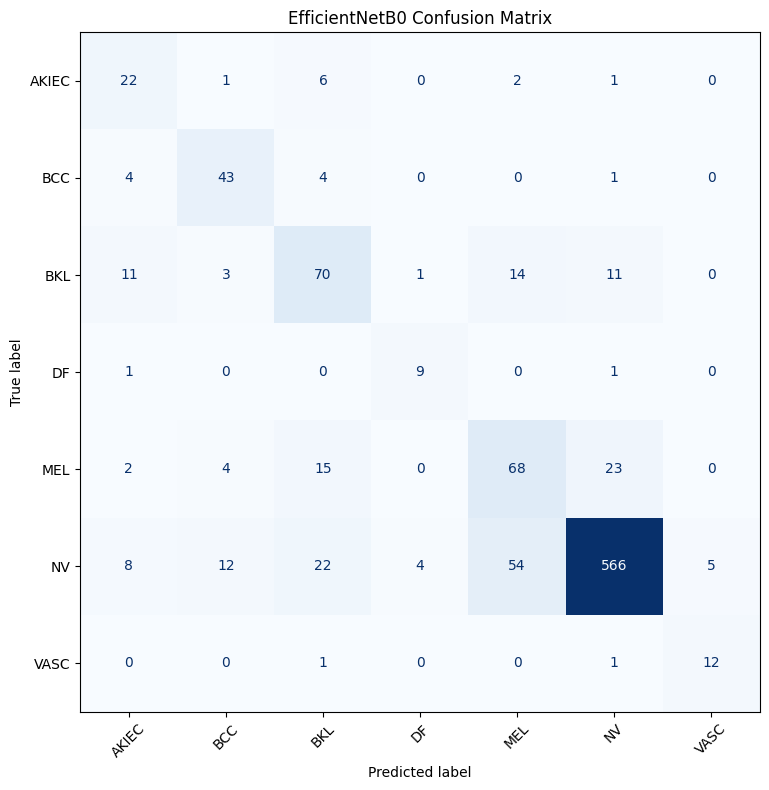

In [223]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)
ax.set_title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()


## Save EfficientNetB0

In [224]:
efficientnet_b0_best.save(
    "/kaggle/working/skinova_efficientnetb0_final.keras"
)
print("EfficientNetB0 best model saved successfully.")


EfficientNetB0 best model saved successfully.


## MODEL 2  EfficientNetB1

## Build EfficientNetB1

In [225]:
from tensorflow.keras.applications import EfficientNetB1

base_b1 = load_efficientnet_backbone(
    EfficientNetB1,
    (IMG_SIZE, IMG_SIZE, 3)
)
base_b1.trainable = False

efficientnet_b1 = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_b1,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

efficientnet_b1.summary()


Loading ImageNet pretrained weights...
SUCCESS: ImageNet pretrained weights loaded.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 8, 8, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,910,094 (26.36 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

## Compile EfficentNetB1

In [226]:
efficientnet_b1.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("EfficientNetB1 compiled successfully.")

EfficientNetB1 compiled successfully.


## Train EfficientNetB1

In [227]:
checkpoint_b1 = ModelCheckpoint(

    "/kaggle/working/skinova_efficientnetb1_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)


history_b1 = efficientnet_b1.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b1
    ]
)

Epoch 1/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.3704 - loss: 1.9028
Epoch 1: val_accuracy improved from None to 0.68831, saving model to /kaggle/working/skinova_efficientnetb1_best.keras

Epoch 1: finished saving model to /kaggle/working/skinova_efficientnetb1_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 180s 275ms/step - accuracy: 0.4847 - loss: 1.4809 - val_accuracy: 0.6883 - val_loss: 0.8220 - learning_rate: 1.0000e-04
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6253 - loss: 1.0227
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 2: val_accuracy improved from 0.68831 to 0.74326, saving model to /kaggle/working/skinova_efficientnetb1_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb1_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 111s 205ms/step - accuracy: 0.6439 - loss: 0.9804 - val_accuracy: 0.7433 - val_loss: 0.7111 - learning_rate: 1.0000e-04
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━

## Plot EfficientNetB1 Training Results

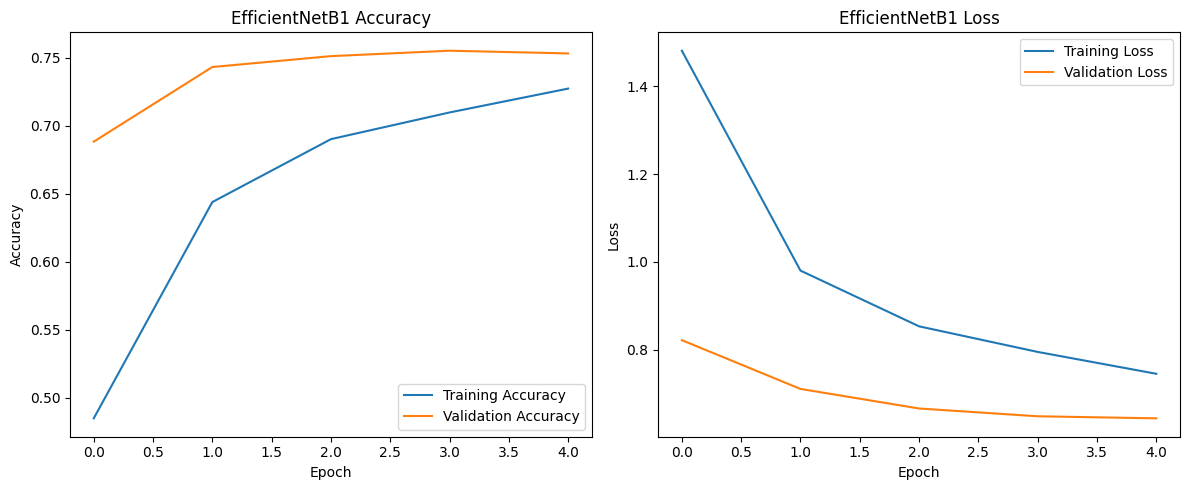

In [228]:
plt.figure(figsize=(12, 5))


# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_b1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_b1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history_b1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_b1.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.tight_layout()
plt.show()

## Fine-Tune EfficientNetB1

In [229]:
# Unfreeze the base model
base_b1.trainable = True


# Freeze earlier layers
for layer in base_b1.layers[:-30]:

    layer.trainable = False


# Keep BatchNormalization layers frozen
for layer in base_b1.layers:

    if isinstance(layer, layers.BatchNormalization):

        layer.trainable = False


# Recompile using a smaller learning rate
efficientnet_b1.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


print("EfficientNetB1 ready for fine-tuning.")

EfficientNetB1 ready for fine-tuning.


In [230]:
history_b1_finetune = efficientnet_b1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b1
    ]
)

efficientnet_b1_best = keras.models.load_model(
    "/kaggle/working/skinova_efficientnetb1_best.keras"
)

print("Best EfficientNetB1 checkpoint reloaded.")


Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.6206 - loss: 1.0499
Epoch 1: val_accuracy did not improve from 0.75524
543/543 ━━━━━━━━━━━━━━━━━━━━ 181s 276ms/step - accuracy: 0.6273 - loss: 1.0256 - val_accuracy: 0.7303 - val_loss: 0.7399 - learning_rate: 1.0000e-05
Epoch 2/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.6451 - loss: 0.9606
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy did not improve from 0.75524
543/543 ━━━━━━━━━━━━━━━━━━━━ 101s 185ms/step - accuracy: 0.6586 - loss: 0.9330 - val_accuracy: 0.7373 - val_loss: 0.7041 - learning_rate: 1.0000e-05
Epoch 3/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6827 - loss: 0.8774
Epoch 3: val_accuracy did not improve from 0.75524
543/543 ━━━━━━━━━━━━━━━━━━━━ 103s 189ms/step - accuracy: 0.6859 - loss: 0.8698 - val_accuracy: 0.7433 - val_loss: 0.6873 - learning_rate: 5.0000e-06
Epoch 4/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - acc

## Compare B0 and B1

In [231]:
# Compare the best checkpoints, not merely the last in-memory epoch.

b0_loss, b0_accuracy = efficientnet_b0_best.evaluate(
    test_generator,
    verbose=0
)

b1_loss, b1_accuracy = efficientnet_b1_best.evaluate(
    test_generator,
    verbose=0
)

comparison = pd.DataFrame({
    "Model": ["EfficientNetB0", "EfficientNetB1"],
    "Test Loss": [b0_loss, b1_loss],
    "Test Accuracy": [b0_accuracy, b1_accuracy]
})

display(comparison)


,Model,Test Loss,Test Accuracy
0,EfficientNetB0,0.567069,0.788423
1,EfficientNetB1,0.664913,0.761477


## Save EfficientNetB1

In [232]:
efficientnet_b1_best.save(
    "/kaggle/working/skinova_efficientnetb1_final.keras"
)
print("EfficientNetB1 best model saved successfully.")


EfficientNetB1 best model saved successfully.


## Create the final prediction function

In [233]:

from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import os

# Use the existing final model
model = efficientnet_b1_best

CLASS_NAMES = CLASSES.copy()


def predict_skin_disease(image_path):
    """
    Predict one skin-lesion class.
    Returns only the highest-probability class and confidence.
    """

    if not isinstance(image_path, (str, os.PathLike)):
        raise TypeError("image_path must be a file path.")

    image_path = str(image_path)

    if not os.path.isfile(image_path):
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    # Resize to the same size used during training
    image = load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb"
    )

    # Convert image to a NumPy array
    image_array = img_to_array(image)

    # Add batch dimension: (1, height, width, 3)
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Predict all 7 class probabilities
    probabilities = model(
        image_array,
        training=False
    ).numpy()[0]

    # Select the class with the highest probability
    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = float(
        probabilities[predicted_index]
    )

    return {
        "predicted_class": predicted_class,
        "confidence": confidence
    }


# Example usage
image_path = "/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg"


result = predict_skin_disease(image_path)

print("Predicted class:", result["predicted_class"])
print("Confidence:", f'{result["confidence"]:.2%}')

Predicted class: NV
Confidence: 99.19%


In [234]:

# TEST PREDICTION ON SAMPLE IMAGES

sample_image_paths = [
    str(DATA_ROOT / "images" / "ISIC_0028394.jpg")
]

for image_path in sample_image_paths:

    result = predict_skin_disease(image_path)

    print("\nImage:", image_path)

    print(
        "Predicted class:",
        result["predicted_class"]
    )

    print(
        "Confidence:",
        f'{result["confidence"]:.2%}'
    )


Image: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
Predicted class: NV
Confidence: 99.19%


# Model Evaluation

## Evaluate EfficientNetB0

In [235]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the best EfficientNetB0 checkpoint
efficientnet_b0_best = load_model(
    "/kaggle/working/skinova_efficientnetb0_best.keras"
)

test_generator.reset()
loss_b0, accuracy_b0 = efficientnet_b0_best.evaluate(
    test_generator,
    verbose=1
)

print(f"EfficientNetB0 Test Loss: {loss_b0:.4f}")
print(f"EfficientNetB0 Test Accuracy: {accuracy_b0:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 436ms/step - accuracy: 0.7884 - loss: 0.5671
EfficientNetB0 Test Loss: 0.5671
EfficientNetB0 Test Accuracy: 0.7884


32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 520ms/step

EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

       AKIEC     0.4583    0.6875    0.5500        32
         BCC     0.6825    0.8269    0.7478        52
         BKL     0.5932    0.6364    0.6140       110
          DF     0.6429    0.8182    0.7200        11
         MEL     0.4928    0.6071    0.5440       112
          NV     0.9371    0.8435    0.8878       671
        VASC     0.7059    0.8571    0.7742        14

    accuracy                         0.7884      1002
   macro avg     0.6447    0.7538    0.6911      1002
weighted avg     0.8147    0.7884    0.7979      1002



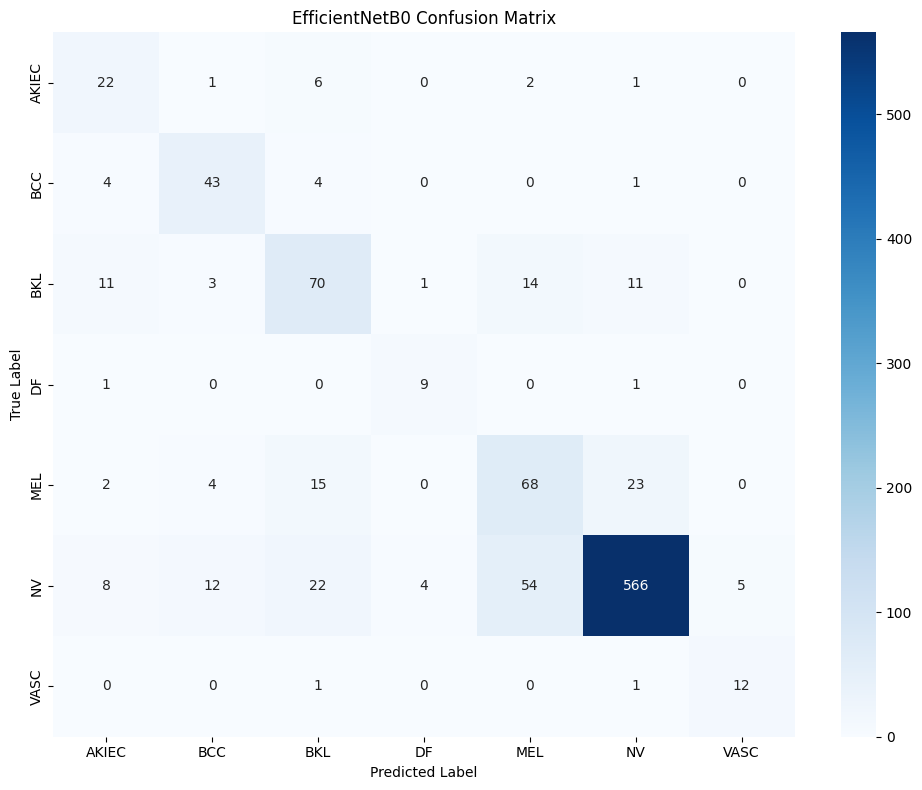

In [236]:
test_generator.reset()

y_pred_b0 = efficientnet_b0_best.predict(
    test_generator,
    verbose=1
)
y_pred_classes_b0 = np.argmax(y_pred_b0, axis=1)
y_true_classes = test_generator.classes

class_labels = CLASSES.copy()

print("\nEfficientNetB0 Classification Report:")
print(
    classification_report(
        y_true_classes,
        y_pred_classes_b0,
        labels=list(range(NUM_CLASSES)),
        target_names=class_labels,
        digits=4,
        zero_division=0
    )
)

cm_b0 = confusion_matrix(
    y_true_classes,
    y_pred_classes_b0,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_b0,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()


## Compare Different Image Resolutions for EfficientNet-B0 

In [237]:


import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.utils import load_img, img_to_array


# Trained EfficientNet-B0 model

b0_model = efficientnet_b0



# Check model

print("Model:", b0_model.name)
print("Model input shape:", b0_model.input_shape)



# Automatically get the input size expected by the model


MODEL_HEIGHT = b0_model.input_shape[1]
MODEL_WIDTH = b0_model.input_shape[2]
MODEL_CHANNELS = b0_model.input_shape[3]

print(
    f"Model expects: "
    f"{MODEL_HEIGHT} × {MODEL_WIDTH} × {MODEL_CHANNELS}"
)


# ------------------------------------------------------------
# Image sizes to compare
# ------------------------------------------------------------

TEST_SIZES = [
    224,
    192,
    176,
    160
]


# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

def predict_from_size(image_path, original_size):

    # First resize the original image to the
    # size being tested
    image = load_img(
        image_path,
        target_size=(original_size, original_size),
        color_mode="rgb"
    )

    image_array = img_to_array(image)

    # Resize the tested image to whatever size the trained
    # model actually expects.
    

    image_array = tf.image.resize(
        image_array,
        (MODEL_HEIGHT, MODEL_WIDTH)
    )

    image_array = image_array.numpy()

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Safety check
    expected_shape = (
        MODEL_HEIGHT,
        MODEL_WIDTH,
        MODEL_CHANNELS
    )

    actual_shape = image_array.shape[1:]

    if actual_shape != expected_shape:
        raise ValueError(
            f"Incorrect input shape. "
            f"Expected {expected_shape}, "
            f"but got {actual_shape}"
        )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    probabilities = b0_model(
        image_array,
        training=False
    ).numpy()[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[predicted_index]
    )

    return predicted_index, confidence


# ------------------------------------------------------------
# Compare image sizes
# ------------------------------------------------------------

for image_path in sample_image_paths:

    print("\n")
    print("=" * 70)
    print("Image:", image_path)
    print("=" * 70)

    predictions = {}
    confidences = {}
    times = {}

    for size in TEST_SIZES:

        start = time.perf_counter()

        predicted_index, confidence = predict_from_size(
            image_path,
            size
        )

        elapsed_time = (
            time.perf_counter() - start
        )

        predictions[size] = predicted_index
        confidences[size] = confidence
        times[size] = elapsed_time

        print(f"\n{size} × {size}")

        print(
            "Prediction:",
            CLASS_NAMES[predicted_index]
        )

        print(
            "Confidence:",
            f"{confidence * 100:.2f}%"
        )

        print(
            "Time:",
            f"{elapsed_time * 1000:.2f} ms"
        )


    # --------------------------------------------------------
    # Compare with 224 × 224 baseline
    # --------------------------------------------------------

    baseline_prediction = predictions[224]

    print("\n")
    print("-" * 70)
    print("Comparison with 224 × 224")
    print("-" * 70)

    for size in TEST_SIZES:

        if size == 224:
            continue

        same_prediction = (
            predictions[size]
            == baseline_prediction
        )

        confidence_difference = (
            abs(
                confidences[size]
                - confidences[224]
            )
            * 100
        )

        print(f"\n{size} × {size}")

        print(
            "Same prediction:",
            same_prediction
        )

        print(
            "Confidence difference:",
            f"{confidence_difference:.2f}%"
        )


print("\n")
print("=" * 70)
print("Comparison completed.")
print("=" * 70)



Model: sequential_3
Model input shape: (None, 240, 240, 3)
Model expects: 240 × 240 × 3


Image: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg

224 × 224
Prediction: DF
Confidence: 70.03%
Time: 298.78 ms

192 × 192
Prediction: DF
Confidence: 71.59%
Time: 281.94 ms

176 × 176
Prediction: DF
Confidence: 90.44%
Time: 279.43 ms

160 × 160
Prediction: DF
Confidence: 68.60%
Time: 286.94 ms


----------------------------------------------------------------------
Comparison with 224 × 224
----------------------------------------------------------------------

192 × 192
Same prediction: True
Confidence difference: 1.56%

176 × 176
Same prediction: True
Confidence difference: 20.41%

160 × 160
Same prediction: True
Confidence difference: 1.42%


Comparison completed.


## Evaluate EfficientNetB1

In [238]:
# Load the best EfficientNetB1 checkpoint
efficientnet_b1_best = load_model(
    "/kaggle/working/skinova_efficientnetb1_best.keras"
)

test_generator.reset()
loss_b1, accuracy_b1 = efficientnet_b1_best.evaluate(
    test_generator,
    verbose=1
)

print(f"EfficientNetB1 Test Loss: {loss_b1:.4f}")
print(f"EfficientNetB1 Test Accuracy: {accuracy_b1:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 519ms/step - accuracy: 0.7615 - loss: 0.6649
EfficientNetB1 Test Loss: 0.6649
EfficientNetB1 Test Accuracy: 0.7615


32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 608ms/step

EfficientNetB1 Classification Report:
              precision    recall  f1-score   support

       AKIEC     0.3519    0.5938    0.4419        32
         BCC     0.5469    0.6731    0.6034        52
         BKL     0.5714    0.4364    0.4948       110
          DF     0.3226    0.9091    0.4762        11
         MEL     0.4951    0.4554    0.4744       112
          NV     0.9048    0.8778    0.8911       671
        VASC     0.7333    0.7857    0.7586        14

    accuracy                         0.7615      1002
   macro avg     0.5609    0.6759    0.5915      1002
weighted avg     0.7774    0.7615    0.7653      1002



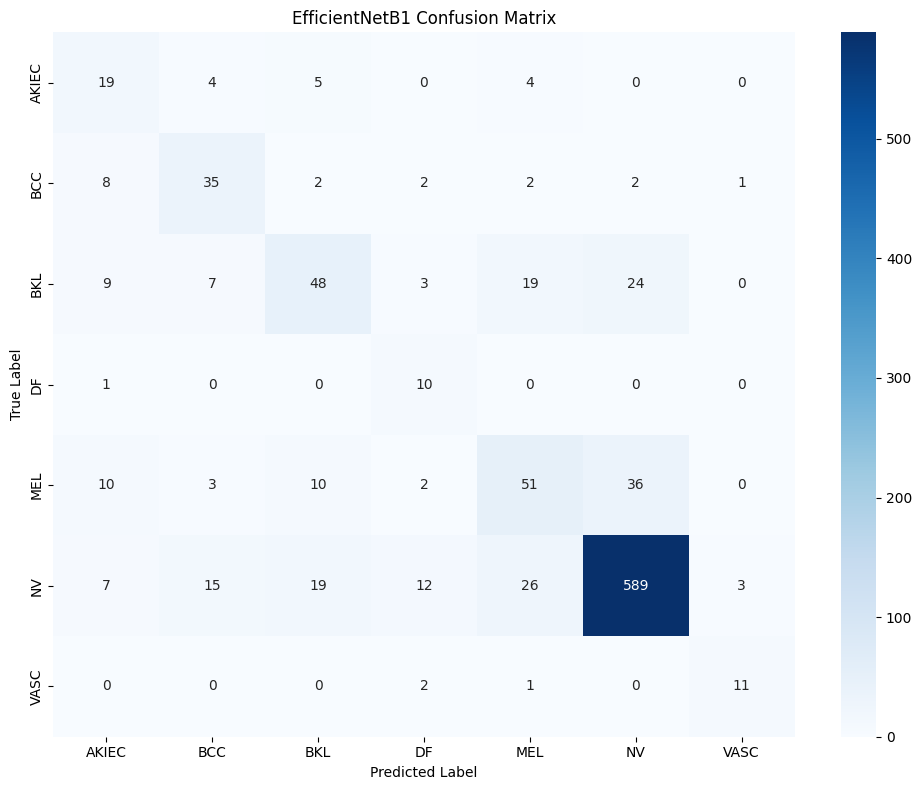

In [239]:
test_generator.reset()

y_pred_b1 = efficientnet_b1_best.predict(
    test_generator,
    verbose=1
)
y_pred_classes_b1 = np.argmax(y_pred_b1, axis=1)

print("\nEfficientNetB1 Classification Report:")
print(
    classification_report(
        y_true_classes,
        y_pred_classes_b1,
        labels=list(range(NUM_CLASSES)),
        target_names=class_labels,
        digits=4,
        zero_division=0
    )
)

cm_b1 = confusion_matrix(
    y_true_classes,
    y_pred_classes_b1,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_b1,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB1 Confusion Matrix")
plt.tight_layout()
plt.show()


## Compare Different Image Resolutions for EfficientNet-B1

In [240]:

# Using the existing trained 240x240 EfficientNet-B1 model


import time
import numpy as np
import tensorflow as tf

from tensorflow.keras.utils import load_img, img_to_array


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

MODEL_SIZE = 240

TEST_SIZES = [
    240,
    224,
    192,
    176,
    160
]


# ------------------------------------------------------------
# PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_from_size(image_path, original_size):

    # Load original image at selected resolution
    image = load_img(
        image_path,
        target_size=(original_size, original_size),
        color_mode="rgb"
    )

    image_array = img_to_array(image)

    # Resize back to 240x240 because the trained
    # EfficientNet-B1 model expects 240x240
    image_array = tf.image.resize(
        image_array,
        (MODEL_SIZE, MODEL_SIZE)
    )

    # Add batch dimension
    image_array = np.expand_dims(
        image_array.numpy(),
        axis=0
    )

    # Prediction
    probabilities = model(
        image_array,
        training=False
    ).numpy()[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[predicted_index]
    )

    return predicted_index, confidence


# ------------------------------------------------------------
# COMPARE DIFFERENT SIZES
# ------------------------------------------------------------

for image_path in sample_image_paths:

    print("\n")
    print("=" * 65)
    print("Image:", image_path)
    print("=" * 65)

    predictions = {}

    for size in TEST_SIZES:

        start = time.perf_counter()

        predicted_index, confidence = predict_from_size(
            image_path,
            size
        )

        elapsed_time = (
            time.perf_counter() - start
        )

        predictions[size] = predicted_index

        print(
            f"\n{size}x{size}"
        )

        print(
            "Prediction:",
            CLASS_NAMES[predicted_index]
        )

        print(
            "Confidence:",
            f"{confidence * 100:.2f}%"
        )

        print(
            "Time:",
            f"{elapsed_time * 1000:.2f} ms"
        )


    # --------------------------------------------------------
    # COMPARE WITH 240x240
    # --------------------------------------------------------

    baseline_prediction = predictions[240]

    print("\n")
    print("-" * 65)
    print("Comparison with 240x240")
    print("-" * 65)

    for size in TEST_SIZES:

        if size == 240:
            continue

        same = (
            predictions[size]
            == baseline_prediction
        )

        print(
            f"{size}x{size}:",
            "Same prediction"
            if same
            else "Different prediction"
        )



Image: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg

240x240
Prediction: NV
Confidence: 99.19%
Time: 429.65 ms

224x224
Prediction: NV
Confidence: 82.52%
Time: 417.56 ms

192x192
Prediction: NV
Confidence: 67.52%
Time: 413.35 ms

176x176
Prediction: NV
Confidence: 49.45%
Time: 413.19 ms

160x160
Prediction: DF
Confidence: 55.40%
Time: 409.29 ms


-----------------------------------------------------------------
Comparison with 240x240
-----------------------------------------------------------------
224x224: Same prediction
192x192: Same prediction
176x176: Same prediction
160x160: Different prediction


# Model Exporting

## Exporting Models for Web Applications

In [241]:
import tensorflow as tf
from pathlib import Path

export_path_b0 = Path("/kaggle/working/efficientnet_b0_savedmodel")
export_path_b1 = Path("/kaggle/working/efficientnet_b1_savedmodel")

def export_saved_model(model, export_path):
    export_path = str(export_path)

    if hasattr(model, "export"):
        model.export(export_path, verbose=0)
    else:
        tf.saved_model.save(model, export_path)

    print(f"Exported: {export_path}")

export_saved_model(efficientnet_b0_best, export_path_b0)
export_saved_model(efficientnet_b1_best, export_path_b1)

print("Model export completed successfully.")

INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b0_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b0_savedmodel/assets


Exported: /kaggle/working/efficientnet_b0_savedmodel
INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b1_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b1_savedmodel/assets


Exported: /kaggle/working/efficientnet_b1_savedmodel
Model export completed successfully.
